# Vitor Hugo da Silva Santos
# RA: 625102765

# Atividade Avaliativa 2 - Classificação de Pedestres usando CNN - PyTorch


Este notebook implementa uma rede neural convolucional (CNN) usando PyTorch para classificar imagens em duas categorias: **Pedestre** e **Não-Pedestre**.
O processo inclui:
- Preparação dos dados
- Definição da Arquitetura
- Construção, treinamento e Avaliação com as previsões da CNN
- Visualização da saída esperada de todas imagens do Dataset


# --- Etapa 1: Carregamento dos Dados ---

In [ ]:
#dados para criação do conjunto de treinamento - isso é só uma pequena parte dos dados
!wget https://www.dropbox.com/sh/v8ljm8r6iihv26s/AAAPwM4-ogZVk9AIxzd1CiRHa
!mv AAAPwM4-ogZVk9AIxzd1CiRHa dataset.zip
!unzip dataset.zip

# --- Etapa 2: Preparação dos Dados ---

In [26]:
import os, cv2, torch, random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Preparar imagens
imagens, saida_esperadas = [], []
for pasta, label in [('Background', 0), ('Pedestrians', 1)]:
    for arquivo in os.scandir(pasta):
        img = cv2.imread(arquivo.path)
        img = cv2.resize(img, (224, 224))
        imagens.append(img)
        saida_esperadas.append(label)

X = np.array(imagens)
y = np.array(saida_esperadas)
XTrain, XTest, YTrain, YTest = train_test_split(X, y, test_size=0.3, random_state=42)

XTrain_tensor = torch.Tensor(XTrain).permute(0, 3, 1, 2) / 255.0
YTrain_tensor = torch.LongTensor(YTrain)
XTest_tensor = torch.Tensor(XTest).permute(0, 3, 1, 2) / 255.0
YTest_tensor = torch.LongTensor(YTest)

train_loader = DataLoader(TensorDataset(XTrain_tensor, YTrain_tensor), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(XTest_tensor, YTest_tensor), batch_size=32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# --- Etapa 2: Definir Arquitetura CNN ---

In [27]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 56 * 56)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = CNN().to(device)


# --- Etapas 3 e 4: Treinamento com Validação / Avaliação no Teste ---


Época 1: Treino = 0.95, Teste = 0.94
Época 2: Treino = 0.95, Teste = 0.78
Época 3: Treino = 0.95, Teste = 0.94
Época 4: Treino = 1.00, Teste = 0.94
Época 5: Treino = 1.00, Teste = 0.89
Época 6: Treino = 1.00, Teste = 0.89
Época 7: Treino = 1.00, Teste = 0.83
Época 8: Treino = 1.00, Teste = 0.89
Época 9: Treino = 1.00, Teste = 0.89
Época 10: Treino = 1.00, Teste = 0.89


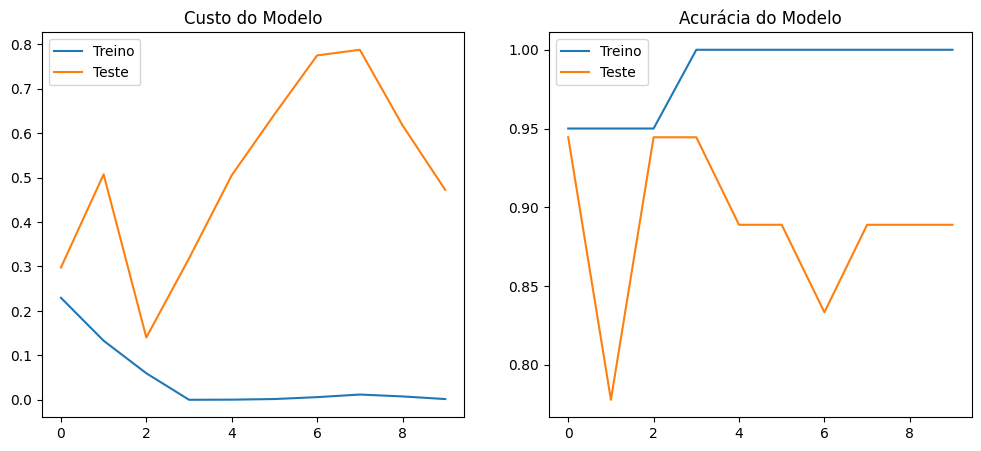

In [29]:
# --- Etapa 3: Treinamento com Validação ---
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_loss, val_loss, train_acc, val_acc = [], [], [], []
for epoch in range(10):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
        correct += (preds.argmax(1) == yb).sum().item()
        total += yb.size(0)
    train_loss.append(loss_sum / len(train_loader))
    train_acc.append(correct / total)

# --- Etapa 4: Avaliação no Teste ---
    model.eval()
    loss_sum, correct, total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss_sum += criterion(preds, yb).item()
            correct += (preds.argmax(1) == yb).sum().item()
            total += yb.size(0)
    val_loss.append(loss_sum / len(test_loader))
    val_acc.append(correct / total)

    print(f"Época {epoch+1}: Treino = {train_acc[-1]:.2f}, Teste = {val_acc[-1]:.2f}")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_loss, label="Treino")
plt.plot(val_loss, label="Teste")
plt.legend()
plt.title("Custo do Modelo")
plt.subplot(1,2,2)
plt.plot(train_acc, label="Treino")
plt.plot(val_acc, label="Teste")
plt.legend()
plt.title("Acurácia do Modelo")
plt.show()


# --- Etapa 5: Visualização da saída esperada de todas imagens do Dataset ---

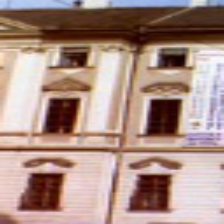

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



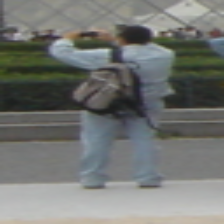

Classificado como: Pedestre
Saída esperada: Pedestre 



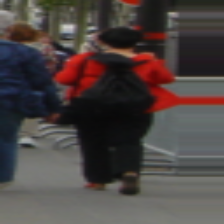

Classificado como: Pedestre
Saída esperada: Pedestre 



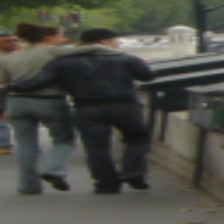

Classificado como: Pedestre
Saída esperada: Pedestre 



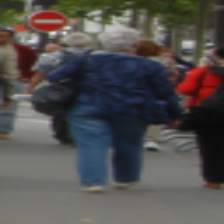

Classificado como: Pedestre
Saída esperada: Pedestre 



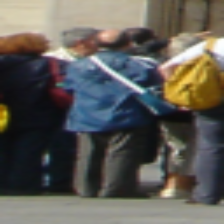

Classificado como: Pedestre
Saída esperada: Pedestre 



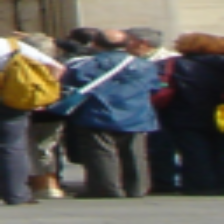

Classificado como: Pedestre
Saída esperada: Pedestre 



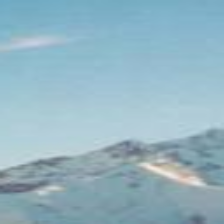

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



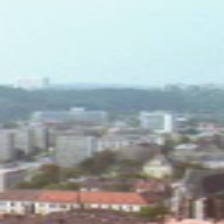

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



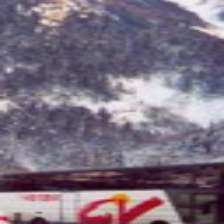

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



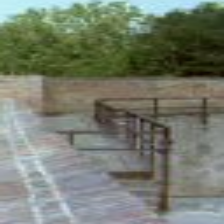

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



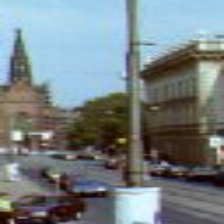

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



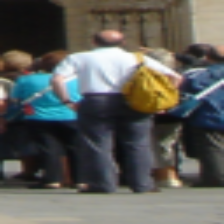

Classificado como: Pedestre
Saída esperada: Pedestre 



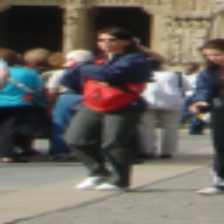

Classificado como: Pedestre
Saída esperada: Pedestre 



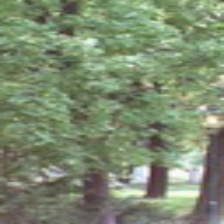

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



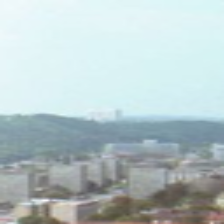

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



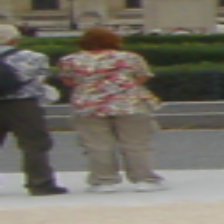

Classificado como: Pedestre
Saída esperada: Pedestre 



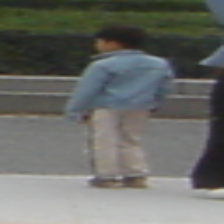

Classificado como: Pedestre
Saída esperada: Pedestre 



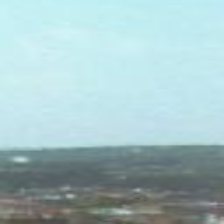

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



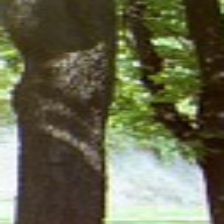

Classificado como: Pedestre
Saída esperada: Não-Pedestre 



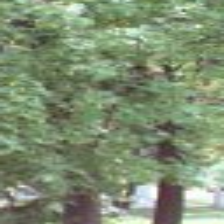

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



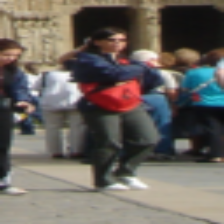

Classificado como: Pedestre
Saída esperada: Pedestre 



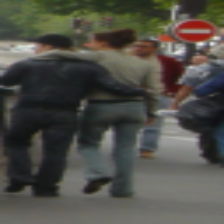

Classificado como: Pedestre
Saída esperada: Pedestre 



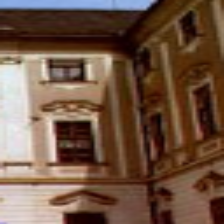

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



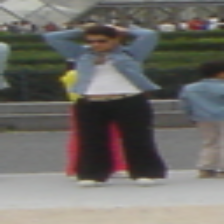

Classificado como: Pedestre
Saída esperada: Pedestre 



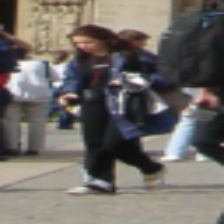

Classificado como: Pedestre
Saída esperada: Pedestre 



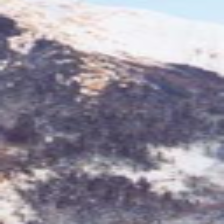

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



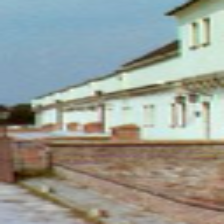

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



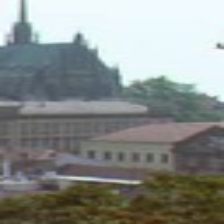

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



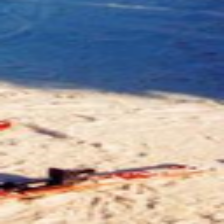

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



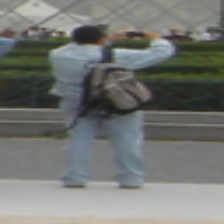

Classificado como: Pedestre
Saída esperada: Pedestre 



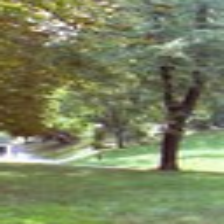

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



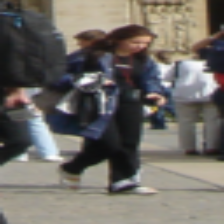

Classificado como: Pedestre
Saída esperada: Pedestre 



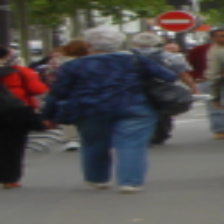

Classificado como: Pedestre
Saída esperada: Pedestre 



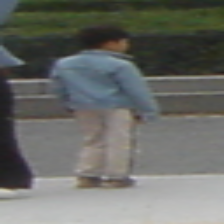

Classificado como: Pedestre
Saída esperada: Pedestre 



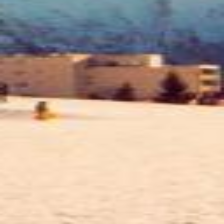

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



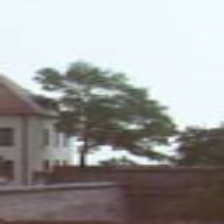

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



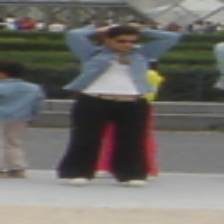

Classificado como: Pedestre
Saída esperada: Pedestre 



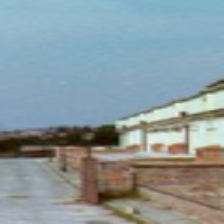

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



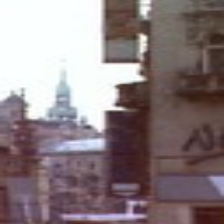

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



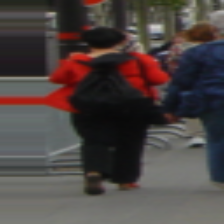

Classificado como: Pedestre
Saída esperada: Pedestre 



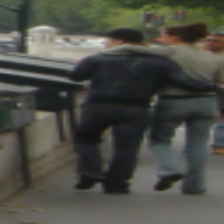

Classificado como: Pedestre
Saída esperada: Pedestre 



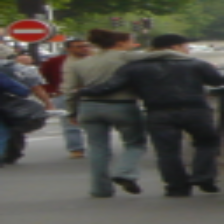

Classificado como: Pedestre
Saída esperada: Pedestre 



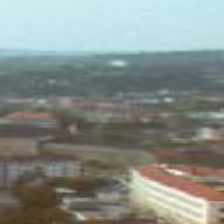

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



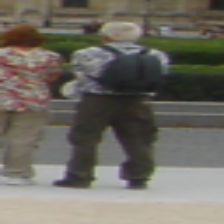

Classificado como: Pedestre
Saída esperada: Pedestre 



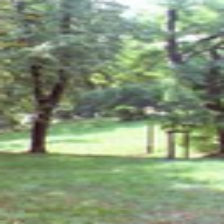

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



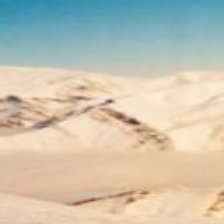

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



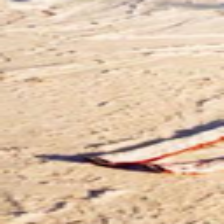

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



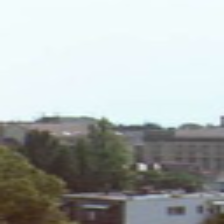

Classificado como: Não-Pedestre
Saída esperada: Não-Pedestre 



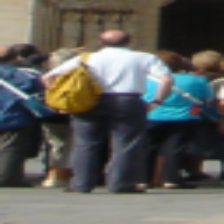

Classificado como: Pedestre
Saída esperada: Pedestre 

Taxa de acerto: 98.00%
Taxa de erro: 2.00%


In [30]:
from google.colab.patches import cv2_imshow

test_images = []
for pasta, label in [('Background', "Não-Pedestre"), ('Pedestrians', "Pedestre")]:
    for arquivo in os.scandir(pasta):
        img = cv2.imread(arquivo.path)
        img = cv2.resize(img, (224, 224))
        test_images.append((img, label))
random.shuffle(test_images)

acertos = erros = 0
for img, real_label in test_images[:50]:
    tensor = torch.Tensor(img).permute(2,0,1).unsqueeze(0).to(device) / 255.0
    model.eval()
    with torch.no_grad():
        output = model(tensor)
    predicted = "Pedestre" if output.argmax() == 1 else "Não-Pedestre"
    cv2_imshow(img)
    print("Classificado como:", predicted)
    print("Saída esperada:", real_label, "\n")
    if predicted == real_label:
        acertos += 1
    else:
        erros += 1

print("Taxa de acerto:", f"{(acertos/(acertos+erros))*100:.2f}%")
print("Taxa de erro:", f"{(erros/(acertos+erros))*100:.2f}%")


# --- Etapa Final: Salvar o Modelo ---

In [31]:
torch.save(model.state_dict(), "modelo_cnn_pedestre.pth")
print("Modelo salvo como 'modelo_cnn_pedestre.pth'")

Modelo salvo como 'modelo_cnn_pedestre.pth'
